In [ ]:
# Run libraries
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np
import scipy.stats as stats
from scipy.stats import norm
from scipy.special import binom
from numba import njit, uint
from scipy.interpolate import interp1d
from scipy.optimize   import brentq

# Income Fluctuation Problem

Let $s_t$ denote the efficiency labor unit, with stochastic transition following a Markov chain:
\begin{align*}
\mathbb{P}(s_{t+1} | s_t, s_{t-1}, ..., s_0) = \mathbb{P}(s_{t+1} | s_t)    
\end{align*}
Intertemporal partial equilibrium decision problem given prices $(w, r)$ and initial conditions $(a_0, s_0)$:
\begin{align*}
\max_{\lbrace c_t,a_{t+1} \rbrace} & \mathbb{E}_0 \sum_{t=0}^{\infty} \beta^t u(c_t) \\
\text{subject to } & c_t + a_{t+1} = (1 + r) a_t + w s_t, \\
\quad &c_t \geq 0, \\
\quad &a_{t+1} \geq -\underline{b}
\end{align*}
The recursive formulation of the above problem is given by:
\begin{align*}
v(a, s) = \max_{a' \geq \underline{b}} \left\lbrace u((1 + r)a + ws - a') + \beta \mathbb{E}[v(a', s') | s] \right\rbrace
\end{align*}
To solve the value function iteration of this problem, first define the discretized asset and idiosyncratic income spaces as:
\begin{align*}
\mathcal{A} &= \{\bar{a}_1 < \bar{a}_2 < \cdots < \bar{a}_n \} \\
\mathcal{S} &= \{\bar{s}_1 < \bar{s}_2 < \cdots < \bar{s}_m \}, \quad \text{with transition matrix } \mathbf{P}
\end{align*}
we substitute the Bellman Equation above by the discretized version:
\begin{align}
v(\bar{a}_i, \bar{s}_h) = \max_{a' \in \mathcal{A}} \left\lbrace u((1 + r)\bar{a}_i + w \bar{s}_h - a') + \beta \sum_{j=1}^{m} P_{hj} v(a', \bar{s}_j) \right\rbrace    
\end{align}

## Auxiliary Functions

In this block, we establish the auxiliary functions which will be used in the Income Fluctuation Problem. These mainly consists of the building blocks of the optimization problem, such as the functions we use to build the grid and discretize the income process

In [ ]:
class ifp_utils():
  '''
  Class that contains auxiliary functions for the Income Fluctuation Problem
  '''
  def __init__(self):
    pass

  @staticmethod
  def u(c, gamma):
    '''
    CRRA Utility function
    '''
    return (c ** (1 - gamma)) / (1 - gamma) if gamma!= 1 else np.log(c)

  @staticmethod
  def u_prime(c, gamma):
    '''
    Derivative of the CRRA Utility function
    '''
    return c ** (-gamma) if gamma != 1 else 1 / c

  @staticmethod
  def power_grid(amin,amax,n,phi=25,nu=5):
    """
    Builds a Power (nonlinear) grid for a given variable of interest (in this case, assets)

    Parameters:
    # amin - minimum value of the grid
    # amax - maximum value of the grid
    # n - Size of the Grid
    # phi - controls the density in the lower part of the grid
    # nu - controls the density in the upper part of the grid
    """

    # 1st step: Construct an n-point equidistant grid
    x_grid = np.linspace(0, 1,n)

    # 2nd step: Apply the non-linear transformation of the grid
    xx_grid = x_grid + phi*x_grid**nu
    xmax = max(xx_grid)
    xmin = min(xx_grid)

    # 3rd step: Obtain the final grid
    a_grid = amin + ((amax-amin)/(xmax-xmin))*xx_grid

    return a_grid


  @staticmethod
  def rouwenhorst_AR1(mu,rho, sigma_e, N):
    """
    Builds the transition matrix and the income grid for an AR(1) process using the Rouwenhorst method.

    Parameters:
    # mu - mean of the AR(1) process
    # rho - persitence of AR(1)
    # sigma_e - standard deviation of the epsilon on AR(1)
    # N - Size of the grid
    """

    #  === Define the parameters which build the discretization === #

    # Grid
    phi = np.sqrt(N-1)*(sigma_e/(np.sqrt(1-rho**2)))
    z_grid = np.linspace(-phi, phi, N) + mu

    # Values of p and q for AR(1) process
    p = (1+ rho)/2
    q = p

    # Initialize the coefficient matrix Pi_N with zeros
    Pi_N = np.zeros((N, N))

    # Iterate over i = 1, 2, ..., N
    for i in range(1, N+1):
        # Initialize a temporary array to store the combined coefficients
        temp_coeffs = np.zeros(N)

        # First expansion: [p + (1 - p)t]^{N-i}
        for k in range(N-i+1):    # (N-i) + (1) - because of range
            coeff1 = binom(N-i, k) * (p**(N-i-k)) * ((1-p)**k)
            # Second expansion: (1 - q + qt)^{i-1}
            for m in range(i):    # (i-1) + (1) - because of range
                coeff2 = binom(i-1, m) * ((1-q)**(i-1-m)) * (q**m)
                # Combine terms for t^(k+m)
                if (k + m) < N:
                    temp_coeffs[k + m] += coeff1 * coeff2

        # Store the coefficients for Φ(t; N, i) in the matrix
        Pi_N[i-1, :] = temp_coeffs

    # Sanity check: Ensure row sums are 1
    row_sums = np.sum(Pi_N, axis=1)
    if not np.allclose(row_sums, 1):
      raise ValueError("Error: Row sums in the transition matrix are not equal to 1.")


    return Pi_N, z_grid

  @staticmethod
  def tauchen_AR1(mu,rho,sigma_e,N,m=3):
        """
        Constructs the N×N transition matrix and the N-point grid for the
        AR(1) process using Tauchen’s (1986) method.

        Parameters
        ----------
        mu       : float   – unconditional mean of y_t
        rho      : float   – AR(1) persistence coefficient  (|ρ| < 1)
        sigma_e  : float   – std. dev. of the i.i.d. shock ε_t
        N        : int     – number of grid points
        m        : float   – width parameter (default 3 → ±3 σ_y)

        Returns
        -------
        Pi       : (N,N)  Numpy array – transition‐probability matrix
        y_grid   : (N,)   Numpy array – state grid for y
        """

        # 1.  Grid construction ------------------------------------------------
        sigma_y = sigma_e / np.sqrt(1.0 - rho**2)      # unconditional σ_y
        y_max   =  m * sigma_y
        y_min   = -m * sigma_y
        d       = (y_max - y_min) / (N - 1)            # grid spacing

        y_grid  = np.linspace(y_min, y_max, N) + mu    # shift by μ

        # 2.  Transition matrix -----------------------------------------------
        Pi = np.zeros((N, N))

        for j in range(N):               # current state index
            for k in range(N):           # next-state index

                if k == 0:               # lower boundary
                    z_upper = (y_grid[0] + d/2.0 - rho * (y_grid[j])) / sigma_e
                    Pi[j, k] = norm.cdf(z_upper)

                elif k == N-1:           # upper boundary
                    z_lower = (y_grid[-1] - d/2.0 - rho * (y_grid[j])) / sigma_e
                    Pi[j, k] = 1.0 - norm.cdf(z_lower)

                else:                    # interior points
                    z_upper = (y_grid[k]   + d/2.0 - rho * (y_grid[j])) / sigma_e
                    z_lower = (y_grid[k]   - d/2.0 - rho * (y_grid[j])) / sigma_e
                    Pi[j, k] = norm.cdf(z_upper) - norm.cdf(z_lower)

        # 3.  (Optional) sanity check – rows must sum to 1
        if not np.allclose(Pi.sum(axis=1), 1.0):
            raise RuntimeError("Tauchen: rows of transition matrix do not sum to 1.")

        return Pi, y_grid

  @staticmethod
  def stationary_dist(P):
        """
        Stationary distribution π solving  π' P = π',  π' 1 = 1,
        obtained from the null-space of (I-P)ᵀ with an additional
        normalising equation.
        Works robustly for large N.

        Parameters
        ----------
        P : (N,N) ndarray – row-stochastic transition matrix.

        Returns
        -------
        π : (N,) ndarray – stationary distribution (non-negative, sums to one).
        """

        P = np.asarray(P)
        if P.ndim != 2 or P.shape[0] != P.shape[1]:
            raise ValueError("P must be a square matrix.")
        if not np.allclose(P.sum(axis=1), 1.0):
            raise ValueError("Rows of P must sum to 1.")

        N = P.shape[0]

        # Build augmented system:              (I - Pᵀ) π = 0
        # add normalising condition            1' π  = 1
        A = np.vstack((np.eye(N) - P.T, np.ones((1, N))))
        b = np.zeros(N + 1)
        b[-1] = 1.0

        # Solve the (N+1)×N least-squares system
        π, *_ = np.linalg.lstsq(A, b, rcond=None)

        # Small negative numerical noise → clip
        π = np.maximum(π, 0)
        π = π / π.sum()          # ensure Σπ = 1

        return π

  @staticmethod
  def simulate_MC(P, z_grid, T, start_state=None, **kwargs):
    """
    Simulates a path from a Markov chain given the transition matrix P and state space z_grid.

    Parameters:
    P          : numpy array of shape (N, N) - The transition matrix
    Y_N        : numpy array of shape (N,)   - The state space grid
    T          : int                         - Number of periods to simulate
    start_state: int or None                 - starting state index, default is None (random start)

    Returns:
    path       : numpy array of shape (T,)   - The simulated path

    Optional (kwargs):
    burn-in    : int                         - Percentage of initial periods to discard of the simulation
    seed       : int                         - Seed for the random number generator
    """

    seed = kwargs.get('seed', None)  # Get seed from kwargs, default to None
    burn_in_percentage = kwargs.get('burn_in', 0)  # Default to 0% if not specified

    # make one local RNG
    if seed is None:
        rng = np.random
    else:
        rng = np.random.RandomState(seed)

    N = P.shape[0]  # Number of states

    # If no start state is given, randomly choose one
    if start_state is None:
        # current_state = np.random.choice(np.arange(N))
        current_state = rng.choice(np.arange(N))
    else:
        current_state = start_state

    # Initialize the array to store the path
    path = np.zeros(T)

    # Simulate the path
    for t in range(T):
        path[t] = z_grid[current_state]  # Record the current state in the path
        # Draw the next state based on the transition probabilities
        # current_state = np.random.choice(np.arange(N), p=P[current_state])
        current_state = rng.choice(np.arange(N), p=P[current_state])


    # Optional Burn-in:

    burn_in_period = int(burn_in_percentage / 100 * T)
    simulated_path = path[burn_in_period:]


    return path



In [ ]:
# Discretizing an AR(1) process - Tauchen
rho = 0.98
sigma_e = np.sqrt(0.06)
mu = -(1/2)*(0.06/1+rho)
Pi_tau_5, z_grid_tau_5 = ifp_utils.tauchen_AR1(mu, rho, sigma_e, 5)
Pi_tau_11, z_grid_tau_11 = ifp_utils.tauchen_AR1(mu, rho, sigma_e, 11)
Pi_rou_5, z_grid_rou_5 = ifp_utils.rouwenhorst_AR1(mu, rho, sigma_e, 5)
Pi_rou_11, z_grid_rou_11 = ifp_utils.rouwenhorst_AR1(mu, rho, sigma_e, 11)

# finding the stationary distribution
pi_star_tau_5 = ifp_utils.stationary_dist(Pi_tau_5)
pi_star_tau_11 = ifp_utils.stationary_dist(Pi_tau_11)
pi_star_rou_5 = ifp_utils.stationary_dist(Pi_rou_5)
pi_star_rou_11 = ifp_utils.stationary_dist(Pi_rou_11)

# Simulating the Tauchen AR(1) process for different gridpoints
T = 1000
seed = 69
y_tau_5 = np.exp(ifp_utils.simulate_MC(Pi_tau_5, z_grid_tau_5, T,seed = seed))
y_rou_5 = np.exp(ifp_utils.simulate_MC(Pi_rou_5, z_grid_rou_5, T,seed = seed))
y_tau_11 = np.exp(ifp_utils.simulate_MC(Pi_tau_11, z_grid_tau_11, T,seed = seed))
y_rou_11 = np.exp(ifp_utils.simulate_MC(Pi_rou_11, z_grid_rou_11, T,seed = seed))
# T = 1000
# y_tauchen = np.zeros((n_sim,T))
# for i_s in range(n_sim):
#   y_tauchen[i_s,:] = np.exp(ifp_utils.simulate_MC(Pi_tau_5, z_grid_tau_5, T,seed = i_s))




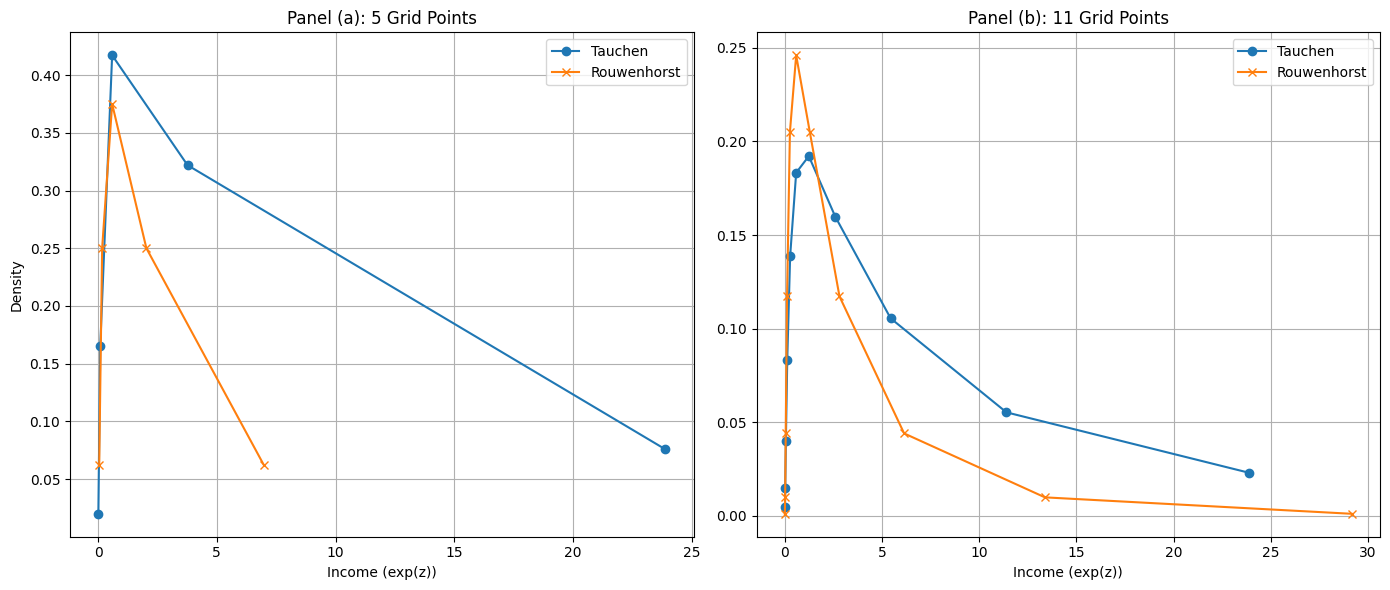

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1x2 subplots

# Plot for 5 grid points
axes[0].plot(np.exp(z_grid_tau_5), pi_star_tau_5, marker='o', label='Tauchen')
axes[0].plot(np.exp(z_grid_rou_5), pi_star_rou_5, marker='x', label='Rouwenhorst')
axes[0].set_xlabel('Income (exp(z))')
axes[0].set_ylabel('Density')
axes[0].set_title('Panel (a): 5 Grid Points')
axes[0].legend()
axes[0].grid(True)

# Plot for 11 grid points
axes[1].plot(np.exp(z_grid_tau_11), pi_star_tau_11, marker='o', label='Tauchen')
axes[1].plot(np.exp(z_grid_rou_11), pi_star_rou_11, marker='x', label='Rouwenhorst')
axes[1].set_xlabel('Income (exp(z))')
# axes[1].set_ylabel('Stationary Distribution')
axes[1].set_title('Panel (b): 11 Grid Points')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


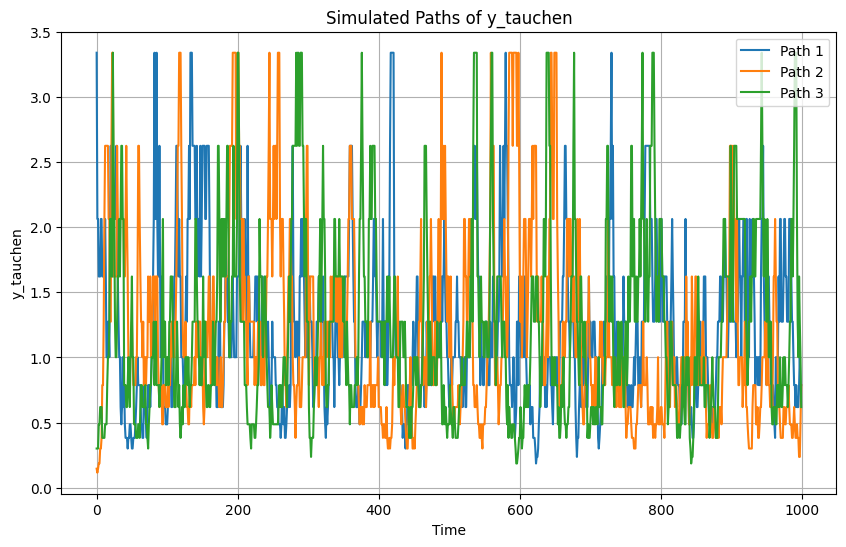

In [ ]:
plt.figure(figsize=(10, 6))  # Adjust figure size as needed

for i in range(y_tauchen.shape[0]):
    plt.plot(y_tauchen[i, :], label=f'Path {i + 1}')

plt.title('Simulated Paths of y_tauchen')
plt.xlabel('Time')
plt.ylabel('y_tauchen')
plt.legend()
plt.grid(True)
plt.show()

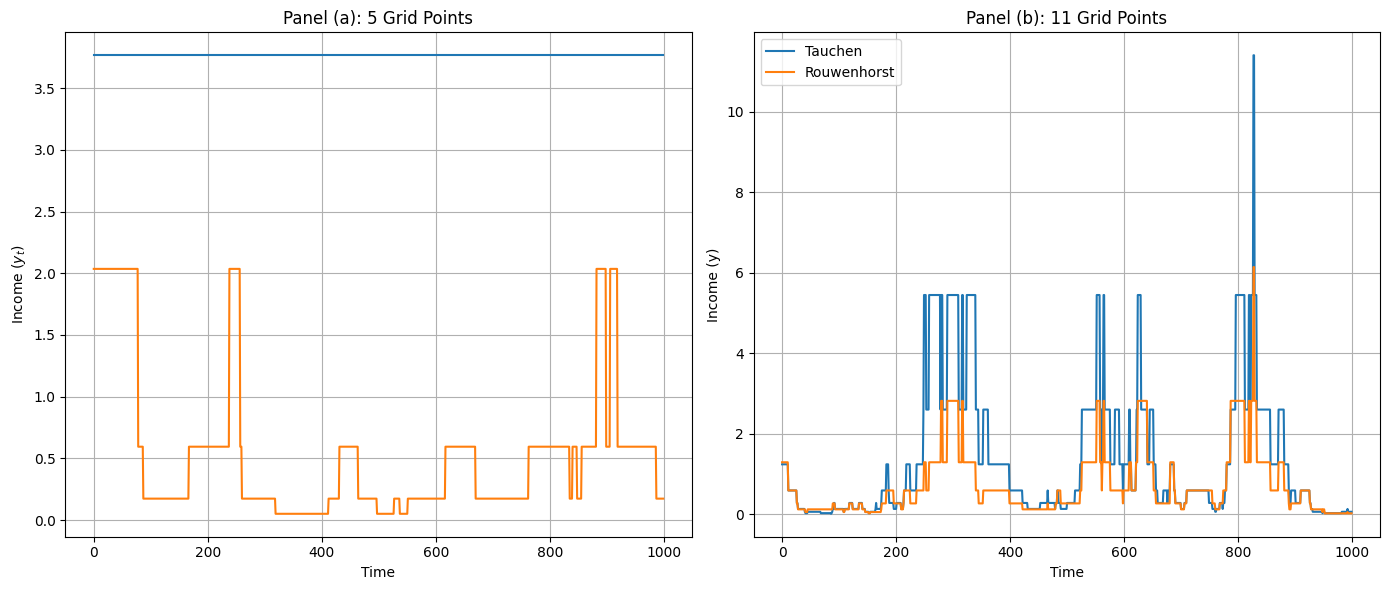

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1x2 subplots

# Plot for 5 grid points
axes[0].plot(y_tau_5, label='Tauchen')
axes[0].plot(y_rou_5, label='Rouwenhorst')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Income ($y_t$)')
axes[0].set_title('Panel (a): 5 Grid Points')
# axes[0].legend()
axes[0].grid(True)

# Plot for 11 grid points
axes[1].plot(y_tau_11, label='Tauchen')
axes[1].plot(y_rou_11, label='Rouwenhorst')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Income (y)')
axes[1].set_title('Panel (b): 11 Grid Points')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

In this block, I define the class which solves the Income Fluctuation Problem in Partial Equilibrium (that is, given prices ($r,w$)). We solve it using each of the methods covered in the numerical appendix of the Lecture Notes in Macroeconomics.


In [ ]:
class income_fluctuation_prob():

  def __init__(self,a_grid,z_grid,Pi,beta,gamma,w,r):

    # Parameters that are invariant with the problem
    self.a_grid = a_grid
    self.z_grid = z_grid
    self.Pi = Pi
    self.beta = beta
    self.gamma = gamma
    self.w = w
    self.r = r

    # # Dictionary of Parameters which can be shocked
    # self.inputs = {
    #     "beta":beta,            # discount factor
    #     "crra":crra,            # crra
    #     "w":w,                  # real wage
    #     "r":r                   # interest rate
    # }

  def Solve_VFI(self,params):
    beta = self.beta
    w = self.w
    r = self.r
    gamma = self.gamma
    # Parametrization of the iteration
    tol = params['tol']
    max_iter = params['max_iter']

    a_grid = self.a_grid
    z_grid = self.z_grid
    Pi = self.Pi

    nz = len(z_grid)
    na = len(a_grid)

    # Create the composite grid using meshgrid
    a_mesh, z_mesh = np.meshgrid(a_grid, z_grid, indexing='ij')

    # Flatten the grids to create the composite grid
    a_composite = a_mesh.flatten()  # Shape: (a_num * Z_num,)
    z_composite = z_mesh.flatten()  # Shape: (a_num * Z_num,)

    # Combine into a single array of shape (a_num * Z_num, 2)
    state_grid = np.column_stack((z_composite, a_composite))

    # Indices for z and k
    z_indices = np.repeat(np.arange(nz), na)
    a_indices = np.tile(np.arange(na), nz)

    # Combine indices into a single array
    state_indices = np.column_stack((z_indices, a_indices))
    policy_indices = np.zeros(na * nz, dtype=int)

    # Now, state_grid contains all possible combinations of z and k
    # state_indices contains the corresponding indices
    A_grid = a_composite[:,np.newaxis]
    Z_grid = z_composite[:,np.newaxis]
    a_prime_array = np.tile(a_grid, (na * nz, 1)) # a matrix


    # == 1st Step: Preallocation of the numerical objects == #
    C = (1+r)*a_mesh + w*np.exp(z_mesh)
    V_old = ifp_utils.u(C,gamma)/(1-beta) # initial guess for the value function
    V_old = V_old.flatten()
    cons = (1 + r) * A_grid + w * np.exp(Z_grid) - a_prime_array
    R_matrix = np.where(cons > 0, ifp_utils.u(cons, gamma), -1e10)

    # == 2nd Step: Iteration == #

    for iter in range(max_iter):
      # Compute the expected value function
      EV_mat = np.zeros((na * nz, na)) # preallocation

      for a_prime_idx in range(na):
        # For each possible k'
        V_aprime = V_old.reshape(na,nz)[a_prime_idx, :]  # Shape: (n_z,)
        EV_aprime = Pi @ V_aprime  # Shape: (n_z,)
        # For all current states, get the expected value depending on current z
        # EV_mat[:, a_prime_idx] = EV_aprime[z_indices]
        EV_mat[:, a_prime_idx] = np.tile(EV_aprime, na)

      # Define the RHS in the Bellman Operator
      RHS = R_matrix + beta*EV_mat
      # Calculate the Bellman Operator
      V_new = np.max(RHS, axis=1)  # New value function
      # Assets next period policy function (indexes)
      policy_indices = np.argmax(RHS, axis=1)  # Indices of optimal a' choices

      # Compute the maximum difference for convergence
      vf_err = np.max(np.abs(V_new - V_old))

      # Update V_old
      V_old = V_new.copy()

      # Print convergence information every 50 iterations
      if iter % 50 == 0:
            print(f'Iteration {iter}: max value function change = {vf_err}')

      # Check for convergence
      if vf_err < tol:
            print(f'Converged after {iter + 1} iterations.')
            break

    else:
        print('VFI did not converge within the maximum number of iterations.')

    # Map policy indices to actual k' values
    a_policy = a_grid[policy_indices]  # Shape: (K_num * Z_num,)

    # Optionally, reshape for analysis
    V = V_old.reshape(na, nz)
    a_policy_reshaped = a_policy.reshape(na, nz)
    sav_policy = a_policy_reshaped - a_mesh
    c_policy = (1+r)*a_mesh + w*np.exp(z_mesh) - a_policy_reshaped

    return V,sav_policy,c_policy,a_policy_reshaped


  def policy_function_iteration(self, params, method="interpolation"):
        """
        Solve the Income Fluctuation Problem by policy‐function iteration.

        params: dict with
          - tol      : convergence tolerance for policy
          - max_iter : maximum number of PFI steps
        method   : "discretization" or "interpolation"
        """
        beta, w, R, gamma    = self.beta, self.w, 1+self.r, self.gamma
        A, Z, Π              = self.a_grid, self.z_grid, self.Pi
        na, nz               = len(A), len(Z)

        # 1) INITIAL GUESS a''(a,z) = just stay put
        a_old = np.tile(A[np.newaxis, :], (nz, 1))    # shape (nz, na)

        # Pre‐compute transition for later
        P = Π  # shape (nz, nz)

        def euler_resid(ih, ia, a_prime, a_policy_guess):
            """
            Compute the Euler‐residual at state (z_i, a_h) when
            next‐period asset = a_prime, given old policy a_policy_guess.

            ih = Index of the z_grid value (scalar)
            ia = Index of the a_grid value (scalar)
            a_prime = Consumption in the next period (scalar)
            a_policy_guess = next period policy function as a function of the idiosyncratic state (matrix)
            """
            zi, ah = Z[ih], A[ia]
            c0     = R*ah + w*np.exp(zi) - a_prime
            if c0 <= 0:
                return +1e8   # effectively constraint binding (overshoot euler residual)
            mu0    = ifp_utils.u_prime(c0, gamma) # Marginal Utility at c0

            # expectation over next‐period z'
            # for each zp index j we need a_policy_guess[j, k'] if a'=A[k']
            # when a' is off‐grid, we'll handle via interpolation below.
            exp_mu = 0.0
            for j in range(nz):
                # next‐period consumption = R*a_prime + w*exp(z_j) - a_old[j, k']
                c1 = R*a_prime + w*np.exp(Z[j]) - (
                      # look up a''(a',z_j) via old policy
                      np.interp(a_prime, A, a_policy_guess[j]) # Given the grid and the old policy function,
                                                               # find the value in a_prime
                    )
                exp_mu += P[ih,j] * ifp_utils.u_prime(c1, gamma)
            return mu0 - beta*R*exp_mu # Return the euler residual

        for it in range(params["max_iter"]):
            a_new = np.empty_like(a_old)

            for ih in range(nz):
                for ia in range(na):
                    ah = A[ia]

                    # 2) check if constraint is binding:
                    c_constr = R*ah + w*np.exp(Z[ih]) - A[0]
                    lhs       = ifp_utils.u_prime(c_constr, gamma)
                    # Calculate the Expected Marginal Utility of Consumption
                    rhs       = beta*R * np.sum(
                                  P[ih,j] *
                                  ifp_utils.u_prime(
                                    R*A[0] + w*np.exp(Z[j]) - a_old[j,0], gamma
                                  )
                                  for j in range(nz)
                                )
                    if lhs >= rhs:
                        # constraint binds
                        a_new[ih,ia] = A[0]
                        continue

                    # 3) interior solution
                    if method == "discretization":
                        # find k s.t. δ(k)<0 <δ(k+1)
                        # compute residuals on grid:
                        res = np.array([
                            euler_resid(ih, ia, A[k], a_old)
                            for k in range(na)
                        ])
                        # locate sign‐change bracket
                        k = np.where((res[:-1] < 0) & (res[1:] > 0))[0]
                        if len(k)==0:
                            # fallback to argmin over entire grid
                            idx = np.argmin(np.abs(res))
                        else:
                            k = k[0]
                            # pick either k or k+1, whichever smaller |δ|
                            idx = k + np.argmin([abs(res[k]), abs(res[k+1])])
                        a_new[ih,ia] = A[idx]

                    else:  # method == "interpolation"
                        # bracket must lie in [A[0], A[-1]]
                        # define root‐finding objective on a in [A[0],A[-1]]
                        def f(a_prime):
                            return euler_resid(ih, ia, a_prime, a_old)
                        # Check whether the chosen next-period asset is out of the grid, and truncate to a_max
                        f_hi = f(A[-1])
                        if f_hi < 0:
                            a_new[ih,ia] = A[-1]
                            continue
                        # we know f(A[0])>0 (we passed constraint test) and f(A[-1])<0
                        a_star = brentq(f, A[0], A[-1])
                        a_new[ih,ia] = a_star

            # 4) check convergence
            diff = np.max(np.abs(a_new - a_old))
            if it % 25 == 0:
              print(f"PFI iter {it}: max policy function change = {diff}")
            if diff < params["tol"]:
                print(f"PFI converged in {it} iters, Δ={diff:.2e}")
                break
            a_old = a_new.copy()
        else:
            print("PFI failed to converge")

        # final policies
        sav   = a_new - A[np.newaxis,:]
        cons  = R*A[np.newaxis,:] + w*np.exp(Z[:,np.newaxis]) - a_new
        return sav, cons, a_new


  def EGM(self,params):
      """
        Solve the Income Fluctuation Problem by the Endogenous Gridpoint Method.

        params: dict with
          - tol      : convergence tolerance for c
          - max_iter : maximum number of EGM steps
      """
      beta, w, R, gamma    = self.beta, self.w, 1+self.r, self.gamma
      A, Z, P              = self.a_grid, self.z_grid, self.Pi
      na, nz               = len(A), len(Z)
      amin                 = A[0]


      # 1st step: Guess for c(a,z)
      z_mesh, a_mesh = np.meshgrid(Z, A, indexing='ij')
      c_old = R*a_mesh + w*np.exp(z_mesh)

      # prellocation for the new policy function
      c_new = np.empty_like(c_old)

      for it in range(params["max_iter"]):
          # Preallocation for the endogenous grid and c_foc
          a_star = np.empty_like(c_old)
          c_foc  = np.empty_like(c_old)
          # 2nd Step: Calculate c_FOC and a_star
          for ih in range(nz):
              for ia in range(na):
                  a_prime = A[ia] # Tomorrow's asset grid point
                  # 2.1 - Calculate the Expected Marginal Utility of Consumption
                  emuc = 0.0
                  for jp in range(nz): # iterating again over z_grid
                    emuc += P[ih,jp]*ifp_utils.u_prime(
                        c_old[jp,ia],gamma
                    )
                  c_foc[ih,ia] = (beta*R*emuc)**(-1/gamma)
                  a_star[ih,ia] = (c_foc[ih,ia] + a_prime - w*np.exp(Z[ih]))/R


          # 3rd Step: Map a_star → a'
          a_policy = np.empty_like(c_old)
          for i in range(nz):
            as_i = a_star[i,:] # Extract the Endogenous grid of assets today given assets tomorrow
            # cfoc_i = c_foc[i,:] # Extract the consumption today given assets tomorrow
            # 3.1 - what is the asset level today that would lead me to be constrained tomorrow?
            a_bind = as_i[0]
            # Loop over assets today
            for h in range(na):
              ah = A[h]
              if ah < a_bind: # 3.2 - Set consumption for all households constrained
                a_policy[i,h] = amin
                # c_new[i,h] = R*ah + w*np.exp(Z[i]) - amin
              else: # 3.3 - Set consumption for all households not constrained
                # 3.3.1 - Find k so that as_i[k] < ah < as_i[k+1]
                # k = np.searchsorted(as_i, ah) - 1
                # # Deal with the case where ah is at the upper boundary
                # if k == na - 1:
                #   k = na - 2

                # # Linear interpolation (as_i[k],as_i[k+1]) for cf_i
                # weight = (ah - as_i[k]) / (as_i[k+1] - as_i[k])
                # c_new[i,h] = cfoc_i[k] + weight * (cfoc_i[k+1] - cfoc_i[k])
                a_policy[i,h] = np.interp(ah,as_i,A)

          # Recover consumption from the budget constraint
          c_new = R*a_mesh + w*np.exp(z_mesh) - a_policy
          # 4th Step: Convergence Check
          diff = np.max(np.abs(c_new-c_old))
          if it % 50 == 0:
            print(f"EGM iter {it}: max policy function change = {diff}")

          if diff < params["tol"]:
            print(f"EGM converged in {it} iters, Δ={diff:.2e}")
            break
          c_old = c_new.copy() # Update for next iteration
      else:
          print("EGM failed to converge")

      # Final Policy Functions:
      # a_policy   = R*A[np.newaxis,:] + w*np.exp(Z[:,np.newaxis]) - c_new
      sav = a_policy - A[np.newaxis,:]
      cons  = c_new
      return sav, cons, a_policy

  def simulate_HH(self,con_policy,sav_policy,T,z0,a0,**kwargs):
    """
    Simulate a path of consumption and savings from the Household in the Income Fluctuation Problem

    Arguments:
    con_policy      : numpy array of shape (n,m) - Policy function of consumption of households
    sav_policy      : numpy array of shape (n,m) - Policy function of savings of households
    T               : int                        - Number of periods to simulate
    z0              : int                        - Initial productivity level (in logs)
    a0              : int                        - Initial level of assets

    Optional (kwargs):
    burn-in         : int                        - Percentage of initial periods to discard of the simulation

    Returns:
    c_path          : numpy array of shape (T,) - Simulated path of consumption
    s_path          : numpy array of shape (T,) - Simulated path of savings
    a_path          : numpy array of shape (T,) - Simulated path of assets
    """

    P = self.Pi
    z_grid = self.z_grid
    a_grid = self.a_grid
    w = self.w


    # 1st: Simulate the Path of Log Productivity given a Markov Process
    z_path = ifp_utils.simulate_MC(P, z_grid, T,
                                   start_state=np.where(z_grid == z0)[0][0],
                                   **kwargs)
    # Convert to Income
    y_path = np.exp(z_path)*w

    # 2nd: Initialize arrays to store the paths
    c_path = np.zeros(T)
    s_path = np.zeros(T)
    a_path = np.zeros(T + 1)
    a_path[0] = a0

    # 3rd: Iterate over periods and simulate the paths
    for t in range(T):
      # Find the Indexes for the path of z and a
      z_idx = np.argmin(np.abs(z_grid - z_path[t]))
      a_idx = np.argmin(np.abs(a_grid - a_path[t]))

      # Simulate the path of consumption and savings
      c_path[t] = con_policy[z_idx, a_idx]
      s_path[t] = sav_policy[z_idx, a_idx]

      # Update the path of assets
      a_path[t + 1] = a_path[t] + s_path[t]


    # Optional Burn-in:
    burn_in_percentage = kwargs.get('burn_in', 0)  # Default to 0% if not specified
    burn_in_period = int(burn_in_percentage / 100 * T)
    y_path = y_path[burn_in_period:]
    a_path = a_path[burn_in_period:]
    c_path = c_path[burn_in_period:]
    s_path = s_path[burn_in_period:]

    return y_path, a_path, c_path, s_path






Generate class for calculating each method


In [ ]:

# Calibration
beta = 0.95
r = 0.02
w = 1
gamma = 2

# Defining the Asset Grid
borrowing_limit = 0
a_max = 20
n_a = 300
a_grid = ifp_utils.power_grid(borrowing_limit,a_max,n_a)

# Discretizing an AR(1) process - Rouwenhorst
rho = 0.9
sigma_e = np.sqrt(0.06)
mu = -(1/2)*(0.06/1+rho)
nz = 5                       # Always set odd number so zero is in the grid
Pi, z_grid = ifp_utils.rouwenhorst_AR1(mu, rho, sigma_e, nz)

# VFI Parameters
params = {
    'tol': 1e-5,
    'max_iter': 2000
}

# Set seed for simulations (income shocks)
seed = 42


ifp = income_fluctuation_prob(a_grid,z_grid,Pi,beta,gamma,w,r)


## 1. Value Function Iteration

In [ ]:
V,sav_policy_vfi,c_policy_vfi,a_policy_reshaped = ifp.Solve_VFI(params)


Iteration 0: max value function change = 32.09144012101821
Iteration 50: max value function change = 0.09121912645580821
Iteration 100: max value function change = 0.0063988635765710455
Iteration 150: max value function change = 0.00048154480244555486
Iteration 200: max value function change = 3.6981147442105566e-05
Converged after 227 iterations.


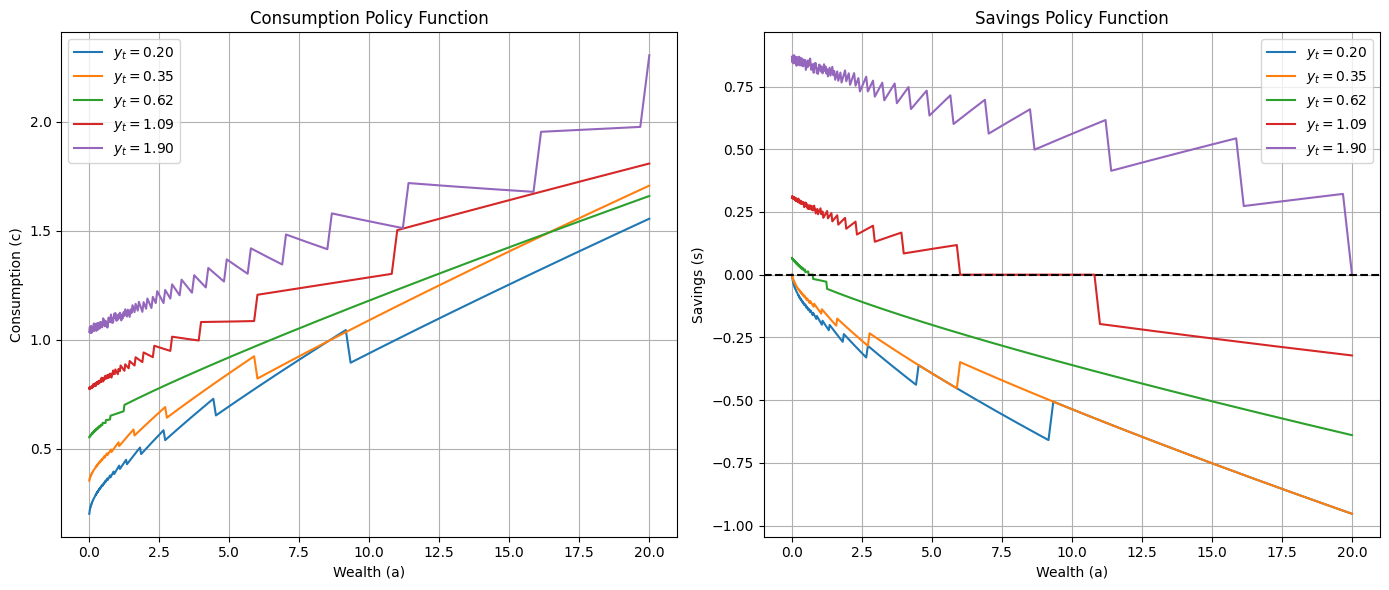

In [ ]:
# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Consumption subplot
for z_idx in range(len(z_grid)):
    y_value = np.exp(z_grid[z_idx])  # Calculate y_t value
    ax1.plot(a_grid, c_policy_vfi[:, z_idx], label=f'$y_t = {y_value:.2f}$')  # Use LaTeX formatting
ax1.set_xlabel('Wealth (a)')
ax1.set_ylabel('Consumption (c)')
ax1.set_title('Consumption Policy Function')
ax1.legend()
ax1.grid(True)

# Savings subplot
for z_idx in range(len(z_grid)):
    y_value = np.exp(z_grid[z_idx])  # Calculate y_t value
    ax2.plot(a_grid, sav_policy_vfi[:, z_idx], label=f'$y_t = {y_value:.2f}$')  # Use LaTeX formatting
ax2.set_xlabel('Wealth (a)')
ax2.set_ylabel('Savings (s)')
ax2.set_title('Savings Policy Function')
ax2.legend()
ax2.axhline(0, color='black', linestyle='--')  # Add horizontal line at y=0
ax2.grid(True)

plt.tight_layout()
plt.show()


## 2. Policy Function Iteration with Interpolation


In [ ]:
sav_pfi, cons_pfi, a_new_pfi = ifp.policy_function_iteration(params, method="interpolation")

<ipython-input-3-585af5340554>:181: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  rhs       = beta*R * np.sum(


PFI iter 0: max policy function change = 0.3088965797324768
PFI iter 25: max policy function change = 0.01341016023308228
PFI iter 50: max policy function change = 0.006356555565446342
PFI iter 75: max policy function change = 0.0010267253485878314
PFI iter 100: max policy function change = 8.286940469659498e-05
PFI converged in 121 iters, Δ=9.86e-06


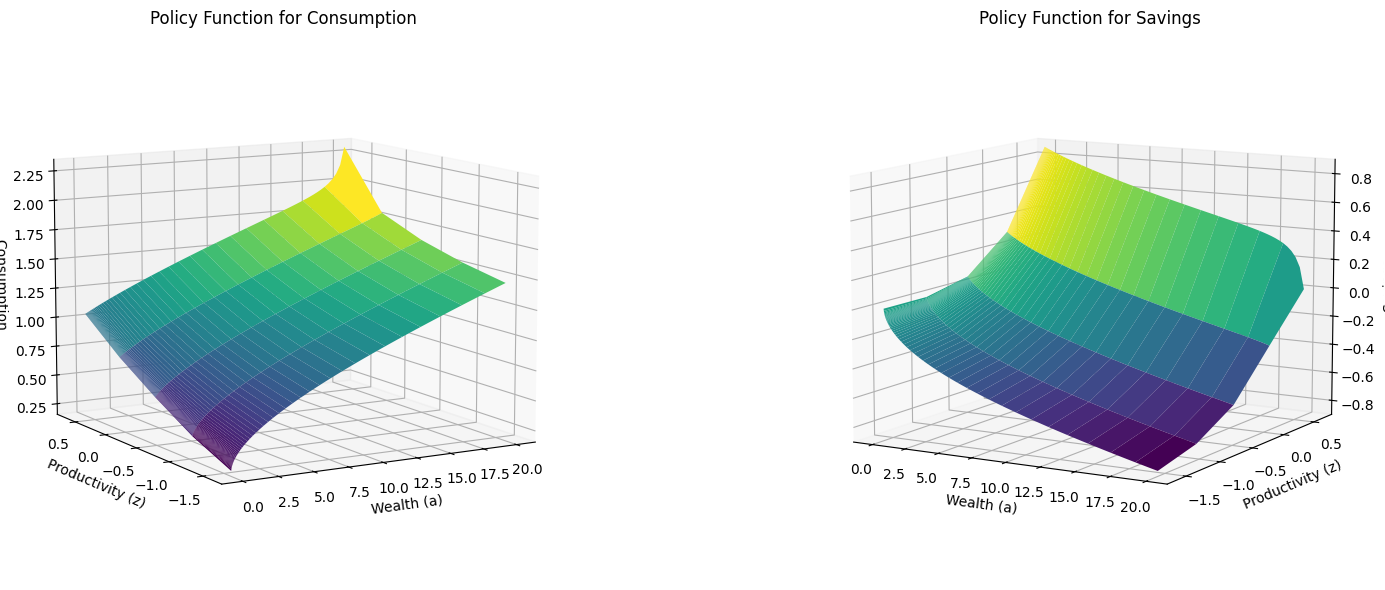

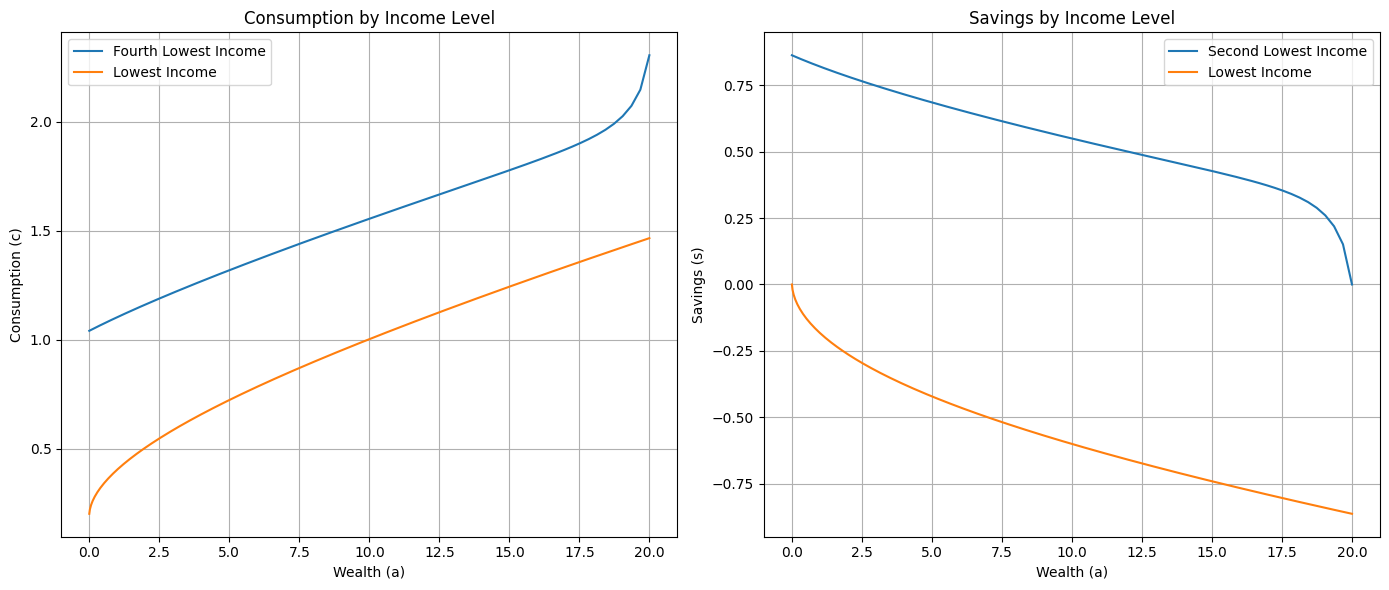

In [ ]:
# Create the figure and axes object
fig = plt.figure(figsize=(18, 6))  # Increased figure size for 3 subplots
ax1 = fig.add_subplot(121, projection='3d')  # Changed to 1 row, 3 columns
ax2 = fig.add_subplot(122, projection='3d')

# Transpose consumption and savings
c_policy_pfi = cons_pfi.T
sav_policy_pfi = sav_pfi.T

n_a_max = 300
n_z_max = 5
selected_a_grid = a_grid[:n_a_max]
selected_z_grid = z_grid[:n_z_max]

# Create the meshgrid using the selected assets
a_mesh, z_mesh = np.meshgrid(selected_a_grid, selected_z_grid, indexing='ij')

# Create the surface plots
ax1.plot_surface(a_mesh, z_mesh, c_policy_pfi[:n_a_max,:n_z_max], cmap=cm.viridis)
ax1.set_title("Policy Function for Consumption")
ax1.set_xlabel("Wealth (a)")
ax1.set_ylabel("Productivity (z)")
ax1.set_zlabel("Consumption")
ax1.view_init(elev=10, azim=-120)

ax2.plot_surface(a_mesh, z_mesh, sav_policy_pfi[:n_a_max,:n_z_max], cmap=cm.viridis)
ax2.set_title("Policy Function for Savings")
ax2.set_xlabel("Wealth (a)")
ax2.set_ylabel("Productivity (z)")
ax2.set_zlabel("Savings")
ax2.view_init(elev=10, azim=-60)


plt.tight_layout() # Adjust layout for better spacing
plt.show()

# Get indices for highest and lowest income levels
z_highest_idx = np.argmax(z_grid)
z_lowest_idx = np.argmin(z_grid)

# Extract consumption for highest and lowest income levels
c_highest_income = c_policy_pfi[:, z_highest_idx]
c_lowest_income = c_policy_pfi[:, z_lowest_idx]
s_highest_income = sav_policy_pfi[:, z_highest_idx]
s_lowest_income = sav_policy_pfi[:, z_lowest_idx]


# Create the plot with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) # Created subplots

# Consumption subplot
ax1.plot(a_grid[:n_a_max], c_highest_income[:n_a_max], label='Fourth Lowest Income')
ax1.plot(a_grid[:n_a_max], c_lowest_income[:n_a_max], label='Lowest Income')
ax1.set_xlabel('Wealth (a)')
ax1.set_ylabel('Consumption (c)')
ax1.set_title('Consumption by Income Level')
ax1.legend()
ax1.grid(True)

# Savings subplot
ax2.plot(a_grid[:n_a_max], s_highest_income[:n_a_max], label='Second Lowest Income')
ax2.plot(a_grid[:n_a_max], s_lowest_income[:n_a_max], label='Lowest Income')
ax2.set_xlabel('Wealth (a)')
ax2.set_ylabel('Savings (s)')
ax2.set_title('Savings by Income Level')
ax2.legend()
ax2.grid(True)

plt.tight_layout() # Adjust layout for better spacing
plt.show()

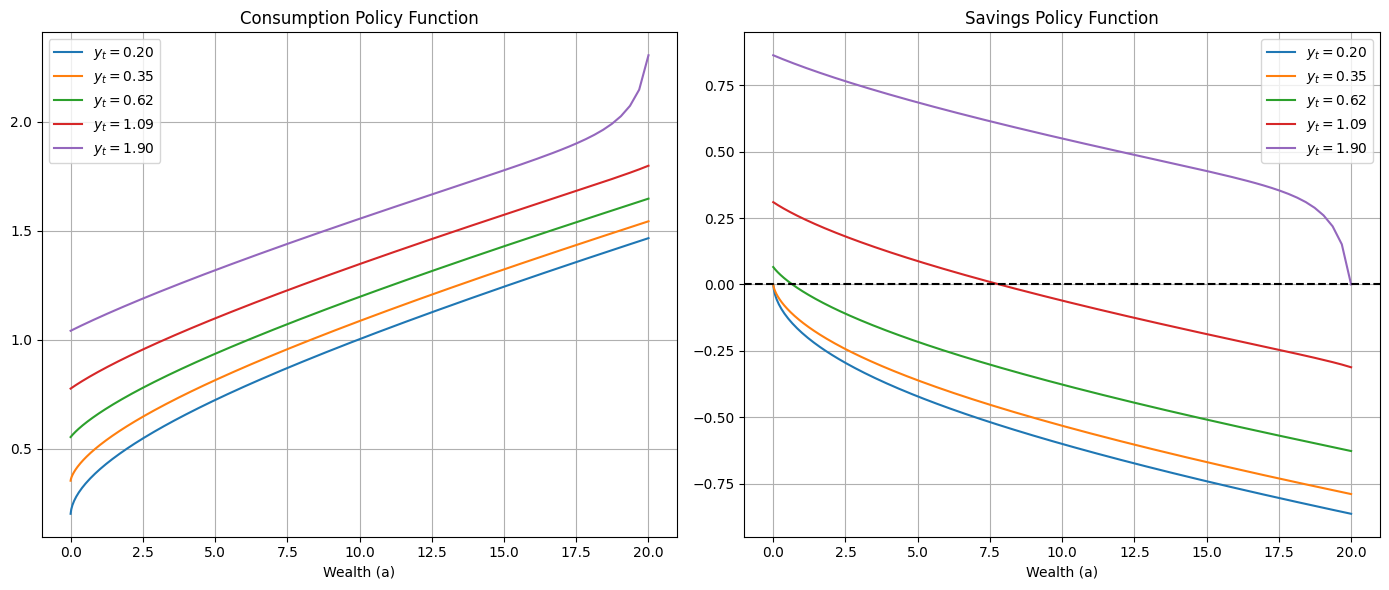

In [ ]:

# Transpose consumption and savings
c_policy_pfi = cons_pfi.T
sav_policy_pfi = sav_pfi.T

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Consumption subplot
for z_idx in range(len(z_grid)):
    y_value = np.exp(z_grid[z_idx])  # Calculate y_t value
    ax1.plot(a_grid, c_policy_pfi[:, z_idx], label=f'$y_t = {y_value:.2f}$')  # Use LaTeX formatting
ax1.set_xlabel('Wealth (a)')
# ax1.set_ylabel('Consumption (c)')
ax1.set_title('Consumption Policy Function')
ax1.legend()
ax1.grid(True)

# Savings subplot
for z_idx in range(len(z_grid)):
    y_value = np.exp(z_grid[z_idx])  # Calculate y_t value
    ax2.plot(a_grid, sav_policy_pfi[:, z_idx], label=f'$y_t = {y_value:.2f}$')  # Use LaTeX formatting
ax2.set_xlabel('Wealth (a)')
# ax2.set_ylabel('Savings (s)')
ax2.set_title('Savings Policy Function')
ax2.legend()
ax2.axhline(0, color='black', linestyle='--')  # Add horizontal line at y=0
ax2.grid(True)

plt.tight_layout()
plt.show()

## 3. Endogenous Grid Method

In [ ]:
sav_egm, cons_egm, a_prime_egm = ifp.EGM(params)

EGM iter 0: max policy function change = 10.090492481032534
EGM iter 50: max policy function change = 0.003097265745783062
EGM iter 100: max policy function change = 2.0425163892667797e-05
EGM converged in 108 iters, Δ=9.10e-06


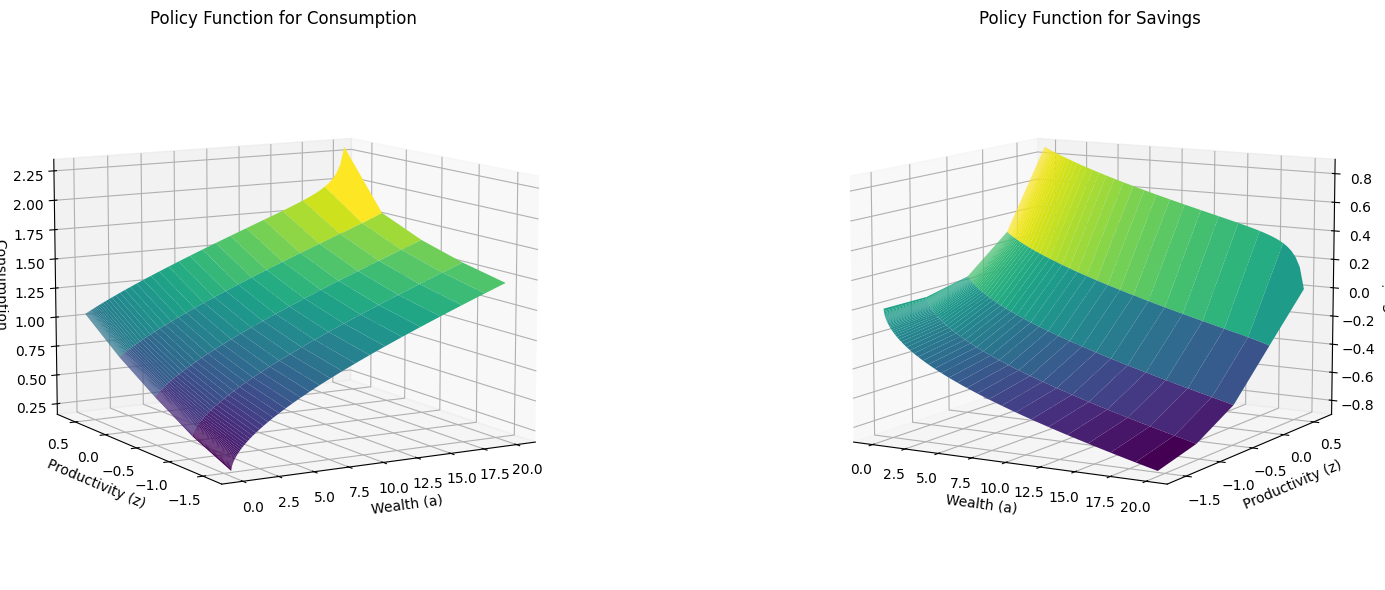

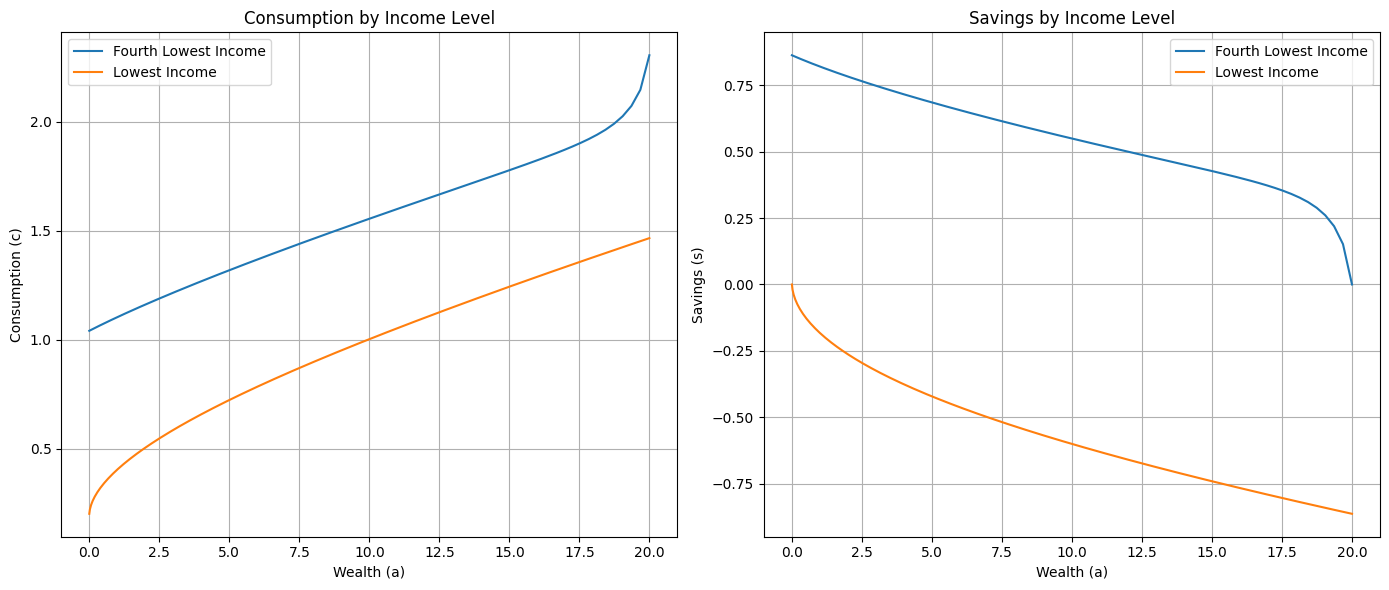

In [ ]:
# Create the figure and axes object
fig = plt.figure(figsize=(18, 6))  # Increased figure size for 3 subplots
ax1 = fig.add_subplot(121, projection='3d')  # Changed to 1 row, 3 columns
ax2 = fig.add_subplot(122, projection='3d')

# Transpose consumption and savings
c_policy_egm = cons_egm.T
sav_policy_egm = sav_egm.T

n_a_max = 300
n_z_max = 5
selected_a_grid = a_grid[:n_a_max]
selected_z_grid = z_grid[:n_z_max]

# Create the meshgrid using the selected assets
a_mesh, z_mesh = np.meshgrid(selected_a_grid, selected_z_grid, indexing='ij')

# Create the surface plots
ax1.plot_surface(a_mesh, z_mesh, c_policy_egm[:n_a_max,:n_z_max], cmap=cm.viridis)
ax1.set_title("Policy Function for Consumption")
ax1.set_xlabel("Wealth (a)")
ax1.set_ylabel("Productivity (z)")
ax1.set_zlabel("Consumption")
ax1.view_init(elev=10, azim=-120)

ax2.plot_surface(a_mesh, z_mesh, sav_policy_egm[:n_a_max,:n_z_max], cmap=cm.viridis)
ax2.set_title("Policy Function for Savings")
ax2.set_xlabel("Wealth (a)")
ax2.set_ylabel("Productivity (z)")
ax2.set_zlabel("Savings")
ax2.view_init(elev=10, azim=-60)


plt.tight_layout() # Adjust layout for better spacing
plt.show()

# Get indices for highest and lowest income levels
z_highest_idx = np.argmax(z_grid)
z_lowest_idx = np.argmin(z_grid)

# Extract consumption for highest and lowest income levels
c_highest_income = c_policy_egm[:, z_highest_idx]
c_lowest_income = c_policy_egm[:, z_lowest_idx]
s_highest_income = sav_policy_egm[:,z_highest_idx]
s_lowest_income = sav_policy_egm[:, z_lowest_idx]


# Create the plot with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) # Created subplots

# Consumption subplot
ax1.plot(a_grid[:n_a_max], c_highest_income[:n_a_max], label='Fourth Lowest Income')
ax1.plot(a_grid[:n_a_max], c_lowest_income[:n_a_max], label='Lowest Income')
ax1.set_xlabel('Wealth (a)')
ax1.set_ylabel('Consumption (c)')
ax1.set_title('Consumption by Income Level')
ax1.legend()
ax1.grid(True)

# Savings subplot
ax2.plot(a_grid[:n_a_max], s_highest_income[:n_a_max], label='Fourth Lowest Income')
ax2.plot(a_grid[:n_a_max], s_lowest_income[:n_a_max], label='Lowest Income')
ax2.set_xlabel('Wealth (a)')
ax2.set_ylabel('Savings (s)')
ax2.set_title('Savings by Income Level')
ax2.legend()
ax2.grid(True)

plt.tight_layout() # Adjust layout for better spacing
plt.show()

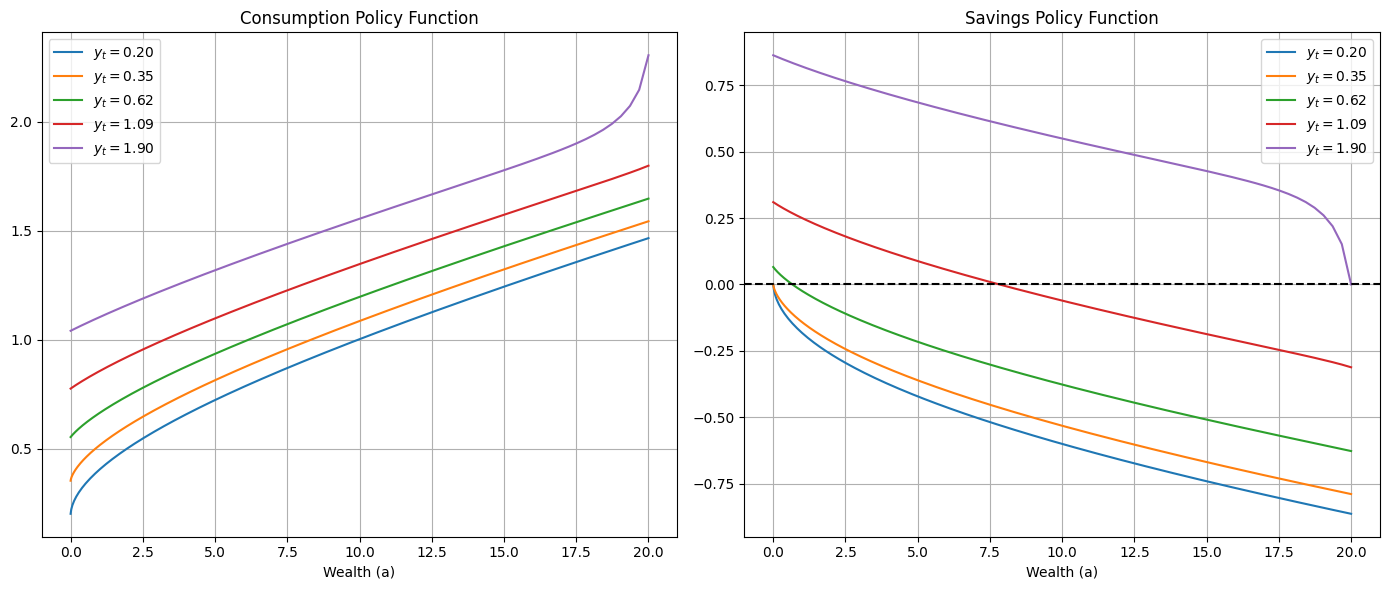

In [ ]:

# Transpose consumption and savings
c_policy_egm = cons_egm.T
sav_policy_egm = sav_egm.T

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Consumption subplot
for z_idx in range(len(z_grid)):
    y_value = np.exp(z_grid[z_idx])  # Calculate y_t value
    ax1.plot(a_grid, c_policy_egm[:, z_idx], label=f'$y_t = {y_value:.2f}$')  # Use LaTeX formatting
ax1.set_xlabel('Wealth (a)')
# ax1.set_ylabel('Consumption (c)')
ax1.set_title('Consumption Policy Function')
ax1.legend()
ax1.grid(True)

# Savings subplot
for z_idx in range(len(z_grid)):
    y_value = np.exp(z_grid[z_idx])  # Calculate y_t value
    ax2.plot(a_grid, sav_policy_egm[:, z_idx], label=f'$y_t = {y_value:.2f}$')  # Use LaTeX formatting
ax2.set_xlabel('Wealth (a)')
# ax2.set_ylabel('Savings (s)')
ax2.set_title('Savings Policy Function')
ax2.legend()
ax2.axhline(0, color='black', linestyle='--')  # Add horizontal line at y=0
ax2.grid(True)

plt.tight_layout()
plt.show()

## Simulating the Income, Savings and Consumption Paths


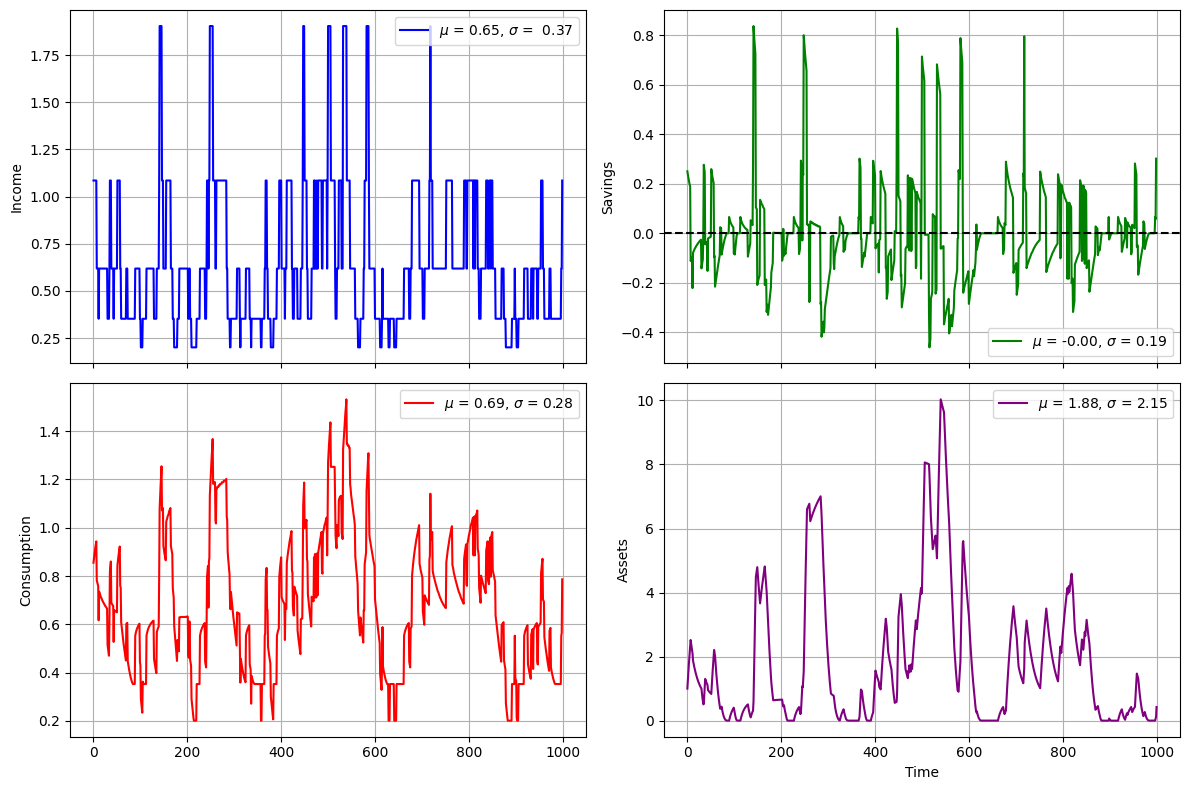

In [ ]:
T = 1000
idx = np.argmin(np.abs(z_grid))
z0 = z_grid[idx]
a0 = 1

y_path, a_path, c_path, s_path = ifp.simulate_HH(cons_egm, sav_egm, T, z0, a0, seed=seed)

# Create the figure and axes objects
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)  # 2x2 grid

# Plot Income (top left)
axes[0, 0].plot(y_path, label='Income', color='blue')
axes[0, 0].set_ylabel('Income')
axes[0, 0].grid(True)
# Calculate and add mean and std to legend
mean_y = np.mean(y_path)
std_y = np.std(y_path)
axes[0, 0].legend([f'$\mu$ = {mean_y:.2f}, $\sigma$ =  {std_y:.2f}'])  # LaTeX formatting


# Plot Savings (top right)
axes[0, 1].plot(s_path, label='Savings', color='green')
axes[0, 1].set_ylabel('Savings')
axes[0, 1].grid(True)
axes[0, 1].axhline(0, color='black', linestyle='--')  # Add horizontal line at y=0
# Calculate and add mean and std to legend
mean_s = np.mean(s_path)
std_s = np.std(s_path)
axes[0, 1].legend([f'$\mu$ = {mean_s:.2f}, $\sigma$ = {std_s:.2f}'])  # LaTeX formatting

# Plot Consumption (bottom left)
axes[1, 0].plot(c_path, label='Consumption', color='red')
axes[1, 0].set_ylabel('Consumption')
axes[1, 0].grid(True)
# Calculate and add mean and std to legend
mean_c = np.mean(c_path)
std_c = np.std(c_path)
axes[1, 0].legend([f'$\mu$ = {mean_c:.2f}, $\sigma$ = {std_c:.2f}'])  # LaTeX formatting

# Plot Assets (bottom right)
axes[1, 1].plot(a_path, label='Assets', color='purple')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Assets')
axes[1, 1].grid(True)
# Calculate and add mean and std to legend
mean_a = np.mean(a_path)
std_a = np.std(a_path)
axes[1, 1].legend([f'$\mu$ = {mean_a:.2f}, $\sigma$ = {std_a:.2f}'])  # LaTeX formatting

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

Comparing simulation between VFI ,PFI and EGM:

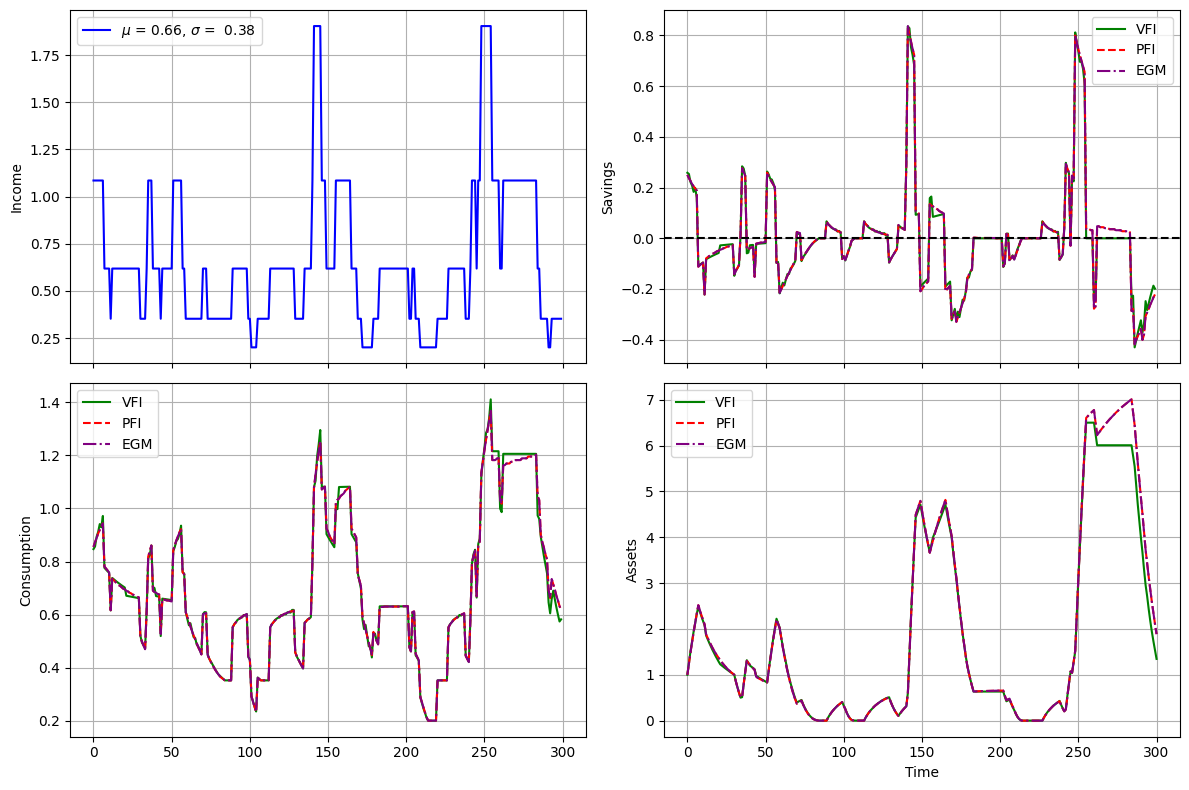

In [ ]:
T=300

# Simulation VFI
y_path_vfi, a_path_vfi, c_path_vfi, s_path_vfi = ifp.simulate_HH(
    c_policy_vfi.T, sav_policy_vfi.T, T, z0, a0, seed=seed)
# Simulation PFI
y_path_pfi, a_path_pfi, c_path_pfi, s_path_pfi = ifp.simulate_HH(
    cons_pfi, sav_pfi, T, z0, a0, seed=seed)
# Simulation EGM
y_path_egm, a_path_egm, c_path_egm, s_path_egm = ifp.simulate_HH(
    cons_egm, sav_egm, T, z0, a0, seed=seed)


# Create the figure and axes objects
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)  # 2x2 grid

# Plot Income (top left) - Same for all methods
axes[0, 0].plot(y_path_vfi, label='Income', color='blue')
axes[0, 0].set_ylabel('Income')
axes[0, 0].grid(True)
mean_y = np.mean(y_path_vfi)  # Using y_path_vfi for mean calculation
std_y = np.std(y_path_vfi)    # Using y_path_vfi for std calculation
axes[0, 0].legend([f'$\mu$ = {mean_y:.2f}, $\sigma$ =  {std_y:.2f}'])

# Plot Savings (top right)
axes[0, 1].plot(s_path_vfi, label='VFI', color='green', linestyle='-')
axes[0, 1].plot(s_path_pfi, label='PFI', color='red', linestyle='--')
axes[0, 1].plot(s_path_egm, label='EGM', color='purple', linestyle='-.')
axes[0, 1].set_ylabel('Savings')
axes[0, 1].grid(True)
axes[0, 1].axhline(0, color='black', linestyle='--')
axes[0, 1].legend()  # Show legend for savings

# Plot Consumption (bottom left)
axes[1, 0].plot(c_path_vfi, label='VFI', color='green', linestyle='-')
axes[1, 0].plot(c_path_pfi, label='PFI', color='red', linestyle='--')
axes[1, 0].plot(c_path_egm, label='EGM', color='purple', linestyle='-.')
axes[1, 0].set_ylabel('Consumption')
axes[1, 0].grid(True)
axes[1, 0].legend()  # Show legend for consumption

# Plot Assets (bottom right)
axes[1, 1].plot(a_path_vfi, label='VFI', color='green', linestyle='-')
axes[1, 1].plot(a_path_pfi, label='PFI', color='red', linestyle='--')
axes[1, 1].plot(a_path_egm, label='EGM', color='purple', linestyle='-.')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Assets')
axes[1, 1].grid(True)
axes[1, 1].legend()  # Show legend for assets


# Adjust layout for better spacing
plt.tight_layout()
plt.show()


Compare the mean and variance of consumption under different degrees of risk aversion


In [ ]:
gamma_alt_1 = 1
gamma_alt_2 = 5
ifp_alt_1 = income_fluctuation_prob(a_grid,z_grid,Pi,beta,gamma_alt_1,w,r)
ifp_alt_2 = income_fluctuation_prob(a_grid,z_grid,Pi,beta,gamma_alt_2,w,r)
sav_egm_alt_1, cons_egm_alt_1, _ = ifp_alt_1.EGM(params)
sav_egm_alt_2, cons_egm_alt_2, _ = ifp_alt_2.EGM(params)
y_path_1, a_path_1, c_path_1, s_path_1 = ifp_alt_1.simulate_HH(cons_egm_alt_1, sav_egm_alt_1, T, z0, a0, seed=seed)
y_path_2, a_path_2, c_path_2, s_path_2 = ifp_alt_2.simulate_HH(cons_egm_alt_2, sav_egm_alt_2, T, z0, a0, seed=seed)


EGM iter 0: max policy function change = 9.99349383327464
EGM iter 50: max policy function change = 0.000650933967083489
EGM converged in 77 iters, Δ=8.67e-06
EGM iter 0: max policy function change = 10.155323695413628
EGM iter 50: max policy function change = 0.0054184582681173765
EGM iter 100: max policy function change = 0.00022576757777414969
EGM converged in 144 iters, Δ=9.56e-06


In [ ]:
assert np.allclose(y_path,y_path_1,y_path_2)

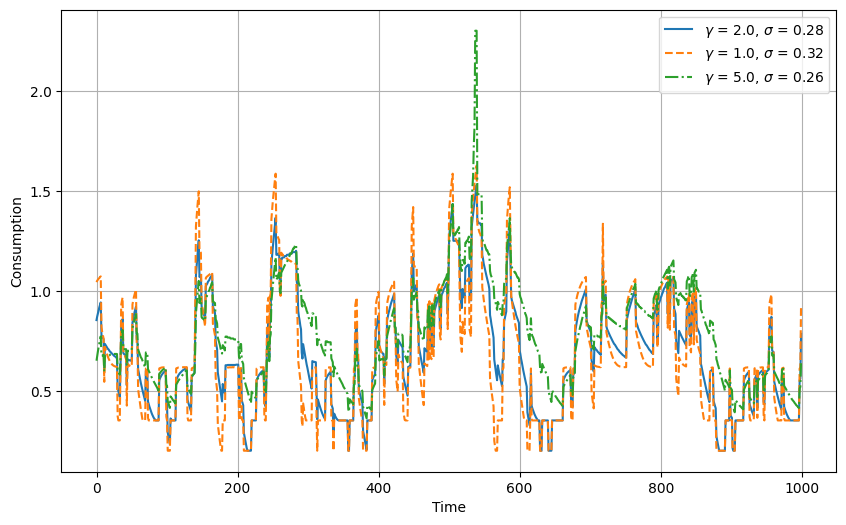

In [ ]:
# Calculate unconditional standard deviations
std_dev = np.std(c_path)
std_dev_1 = np.std(c_path_1)
std_dev_2 = np.std(c_path_2)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(c_path, label=f'$\gamma$ = {gamma:.1f}, $\sigma$ = {std_dev:.2f}')
plt.plot(c_path_1, linestyle = "--",label=f'$\gamma$ = {gamma_alt_1:.1f}, $\sigma$ = {std_dev_1:.2f}')
plt.plot(c_path_2, linestyle = "-.",label=f'$\gamma$ = {gamma_alt_2:.1f}, $\sigma$ = {std_dev_2:.2f}')

# Customize the plot
plt.xlabel('Time')
plt.ylabel('Consumption')
# plt.title('Consumption Paths under Different Risk Aversion')
plt.legend()
plt.grid(True)

Compare the saving-income ratio as uncertainty arises, $\sigma^2_\varepsilon \in \{0.01,0.06,0.12\}$

In [ ]:
T=1000

sigma_e_a1 = np.sqrt(0.01)
sigma_e_a2 = np.sqrt(0.12)
mu_a1 = -(1/2)*(0.01/1+rho)
mu_a2 = -(1/2)*(0.12/1+rho)

Pi_a1, z_grid_a1 = ifp_utils.rouwenhorst_AR1(mu_a1, rho, sigma_e_a1, nz)
Pi_a2, z_grid_a2 = ifp_utils.rouwenhorst_AR1(mu_a2, rho, sigma_e_a2, nz)

z0_alt1 = z_grid_a1[np.argmin(np.abs(z_grid_a1))]
z0_alt2 = z_grid_a2[np.argmin(np.abs(z_grid_a2))]

ifp_alt_1 = income_fluctuation_prob(a_grid,z_grid_a1,Pi_a1,beta,gamma,w,r)
ifp_alt_2 = income_fluctuation_prob(a_grid,z_grid_a2,Pi_a2,beta,gamma,w,r)
sav_egm_alt_1, cons_egm_alt_1, _ = ifp_alt_1.EGM(params)
sav_egm_alt_2, cons_egm_alt_2, _ = ifp_alt_2.EGM(params)
y_path_1, a_path_1, c_path_1, s_path_1 = ifp_alt_1.simulate_HH(cons_egm_alt_1, sav_egm_alt_1, T, z0_alt1, a0, seed=seed)
y_path_2, a_path_2, c_path_2, s_path_2 = ifp_alt_2.simulate_HH(cons_egm_alt_2, sav_egm_alt_2, T, z0_alt2, a0, seed=seed)

# Calculate the saving-income ratio path:
sav_inc_ratio_baseline = s_path/y_path
sav_inc_ratio_alt_1 = s_path_1/y_path_1
sav_inc_ratio_alt_2 = s_path_2/y_path_2





EGM iter 0: max policy function change = 10.03163832593402
EGM iter 50: max policy function change = 0.0028238819034385187
EGM converged in 90 iters, Δ=8.75e-06
EGM iter 0: max policy function change = 10.178046117426748
EGM iter 50: max policy function change = 0.003015338684978275
EGM iter 100: max policy function change = 2.0675847370199563e-05
EGM converged in 108 iters, Δ=9.23e-06


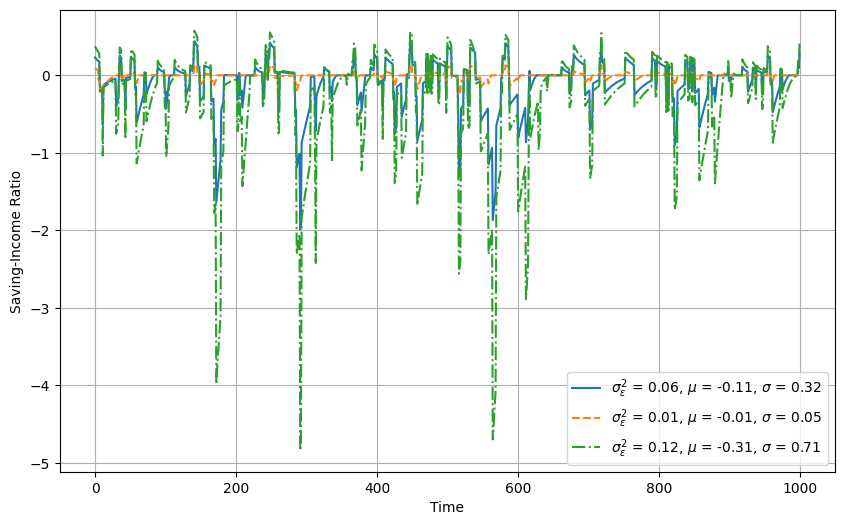

In [ ]:
# Calculate unconditional standard deviations
std_dev = np.std(sav_inc_ratio_baseline)
std_dev_1 = np.std(sav_inc_ratio_alt_1)
std_dev_2 = np.std(sav_inc_ratio_alt_2)

mean = np.mean(sav_inc_ratio_baseline)
mean_1 = np.mean(sav_inc_ratio_alt_1)
mean_2 = np.mean(sav_inc_ratio_alt_2)


# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(sav_inc_ratio_baseline, label=f'$\sigma^2_\epsilon$ = 0.06, $\mu$ = {mean:.2f}, $\sigma$ = {std_dev:.2f}')
plt.plot(sav_inc_ratio_alt_1, linestyle="--", label=f'$\sigma^2_\epsilon$ = 0.01, $\mu$ = {mean_1:.2f}, $\sigma$ = {std_dev_1:.2f}')
plt.plot(sav_inc_ratio_alt_2, linestyle="-.", label=f'$\sigma^2_\epsilon$ = 0.12, $\mu$ = {mean_2:.2f}, $\sigma$ = {std_dev_2:.2f}')

# Customize the plot
plt.xlabel('Time')
plt.ylabel('Saving-Income Ratio')
# plt.title('Consumption Paths under Different Risk Aversion')
plt.legend()
plt.grid(True)

Impose the Natural Borrowing Limit:
\begin{align}
\underline{a} = -\frac{y_{min}}{r}
\end{align}

In [ ]:
nbl = -w*np.exp(z_grid[0])/r

# Defining the Asset Grid
a_grid_nat = ifp_utils.power_grid(nbl,a_max,n_a)

ifp_nat = income_fluctuation_prob(a_grid_nat,z_grid,Pi,beta,gamma,w,r)


In [ ]:
nbl

np.float64(-10.055502846084917)

simulate consumption, assets and savings under the natural borrowing limit

In [ ]:
sav_egm_nat, cons_egm_nat, a_prime_egm_nat = ifp_nat.EGM(params)

EGM iter 0: max policy function change = 10.090493199772805
EGM iter 50: max policy function change = 0.008538792942729856
EGM iter 100: max policy function change = 0.0003290256895240873
EGM converged in 145 iters, Δ=9.61e-06


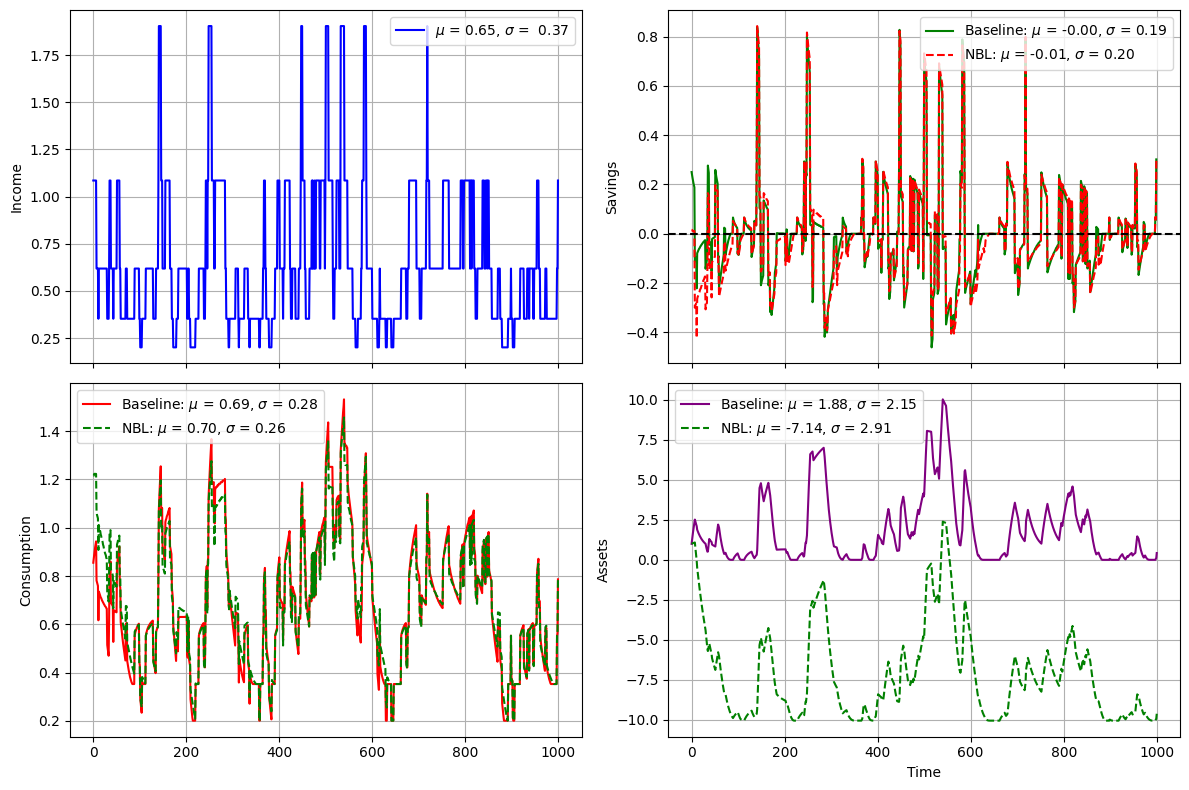

In [ ]:
y_path_nat, a_path_nat, c_path_nat, s_path_nat = ifp_nat.simulate_HH(cons_egm, sav_egm, T, z0, a0, seed=seed)

# Create the figure and axes objects
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)  # 2x2 grid

# Plot Income (top left) - Same for both economies
axes[0, 0].plot(y_path, label='Income', color='blue')  # Only plot y_path once
axes[0, 0].set_ylabel('Income')
axes[0, 0].grid(True)
# Calculate and add mean and std to legend (only for y_path)
mean_y = np.mean(y_path)
std_y = np.std(y_path)
axes[0, 0].legend([f'$\mu$ = {mean_y:.2f}, $\sigma$ =  {std_y:.2f}'])  # LaTeX formatting

# Plot Savings (top right)
axes[0, 1].plot(s_path, label='Baseline', color='green')
axes[0, 1].plot(s_path_nat, label='NBL', color='red', linestyle='--')
axes[0, 1].set_ylabel('Savings')
axes[0, 1].grid(True)
axes[0, 1].axhline(0, color='black', linestyle='--')
# Calculate and add mean and std to legend for baseline and NBL savings
mean_s = np.mean(s_path)
std_s = np.std(s_path)
mean_s_nat = np.mean(s_path_nat)
std_s_nat = np.std(s_path_nat)
axes[0, 1].legend([f'Baseline: $\mu$ = {mean_s:.2f}, $\sigma$ = {std_s:.2f}',
                  f'NBL: $\mu$ = {mean_s_nat:.2f}, $\sigma$ = {std_s_nat:.2f}'])

# Plot Consumption (bottom left)
axes[1, 0].plot(c_path, label='Baseline', color='red')
axes[1, 0].plot(c_path_nat, label='NBL', color='green', linestyle='--')
axes[1, 0].set_ylabel('Consumption')
axes[1, 0].grid(True)
# Calculate and add mean and std to legend for baseline and NBL consumption
mean_c = np.mean(c_path)
std_c = np.std(c_path)
mean_c_nat = np.mean(c_path_nat)
std_c_nat = np.std(c_path_nat)
axes[1, 0].legend([f'Baseline: $\mu$ = {mean_c:.2f}, $\sigma$ = {std_c:.2f}',
                  f'NBL: $\mu$ = {mean_c_nat:.2f}, $\sigma$ = {std_c_nat:.2f}'])

# Plot Assets (bottom right)
axes[1, 1].plot(a_path, label='Baseline', color='purple')
axes[1, 1].plot(a_path_nat, label='NBL', color='green', linestyle='--')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Assets')
axes[1, 1].grid(True)
# Calculate and add mean and std to legend for baseline and NBL assets
mean_a = np.mean(a_path)
std_a = np.std(a_path)
mean_a_nat = np.mean(a_path_nat)
std_a_nat = np.std(a_path_nat)
axes[1, 1].legend([f'Baseline: $\mu$ = {mean_a:.2f}, $\sigma$ = {std_a:.2f}',
                  f'NBL: $\mu$ = {mean_a_nat:.2f}, $\sigma$ = {std_a_nat:.2f}'])

# Adjust layout for better spacing
plt.tight_layout()
plt.show()
